# **V-JEPA**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import math

# Set random seed for reproducibility
torch.manual_seed(42)
random.seed(42)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

# **Spatio-Temporal 3D Tokenizer**



In [2]:
class VideoPatchEmbedder(nn.Module):
    """Turns a Video Tensor [B, C, T, H, W] into 3D Spatio-Temporal Tokens."""
    def __init__(self, img_size=32, patch_size=8, num_frames=4, tubelet_size=2, in_chans=3, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_frames = num_frames
        self.tubelet_size = tubelet_size

        # Total tokens calculated as: (T/tubelet) * (H/patch) * (W/patch)
        self.num_tokens = (num_frames // tubelet_size) * (img_size // patch_size) * (img_size // patch_size)

        # 3D Convolution kernel projects space and time features simultaneously
        self.proj = nn.Conv3d(
            in_chans, embed_dim,
            kernel_size=(tubelet_size, patch_size, patch_size),
            stride=(tubelet_size, patch_size, patch_size)
        )

    def forward(self, x):
        # Input shape: [Batch, Channels, Time, Height, Width]
        x = self.proj(x)                  # Output shape: [B, embed_dim, T_new, H_new, W_new]
        x = x.flatten(2).transpose(1, 2)  # Reshape to sequence layout: [B, Num_Tokens, embed_dim]
        return x

# **Predictor Module**

In [3]:
class VJEPAPredictor(nn.Module):
    """Predictor transformer block designed to fill missing space-time latent tokens."""
    def __init__(self, embed_dim=128, num_layers=2):
        super().__init__()
        pred_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(pred_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x)

# **V-JEPA Core Model**

In [4]:
class VideoJEPA(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.tokenizer = VideoPatchEmbedder(embed_dim=embed_dim)
        num_tokens = self.tokenizer.num_tokens

        # 3D Coordinate-based Spatio-Temporal Positional Embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, embed_dim))
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) # Learnable [mask] placeholder

        # Siamese Tracker Networks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=4, dim_feedforward=256,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.context_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.target_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.predictor = VJEPAPredictor(embed_dim=embed_dim)

        # Freeze target encoder weights from normal SGD updates
        for param in self.target_encoder.parameters():
            param.requires_grad = False

        # Initialization
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)
        self.apply(init_weights)

    def update_target_weights(self, momentum=0.996):
        """The EMA Engine: Target tracks context slowly to prevent representation collapse."""
        for c_param, t_param in zip(self.context_encoder.parameters(), self.target_encoder.parameters()):
            t_param.data = t_param.data * momentum + c_param.data * (1.0 - momentum)

    def forward(self, video):
        B = video.size(0)

        # 1. Spatio-Temporal tokenization + global coordinates injection
        tokens = self.tokenizer(video)
        tokens = tokens + self.pos_embed

        # 2. Section 3.2: 3D Multi-Block Masking Logic
        # We sample visible context indices (~25%) and leave the rest as hidden targets (~75%)
        num_tokens = tokens.size(1)
        indices = list(range(num_tokens))
        random.shuffle(indices)

        context_len = max(1, int(num_tokens * 0.25))
        context_idx = sorted(indices[:context_len])
        target_idx = sorted(indices[context_len:])

        # 3. Separate visible vs hidden items
        context_tokens = tokens[:, context_idx, :]

        # 4. Forward passes through Context and Target Encoders
        context_feats = self.context_encoder(context_tokens)

        with torch.no_grad():
            # Targets are passed strictly into the EMA target encoder path
            true_target_feats = self.target_encoder(tokens[:, target_idx, :])

        # 5. Build sequence for the Predictor
        pred_input = torch.zeros(B, num_tokens, tokens.size(-1), device=video.device)

        # Insert known visible context representations
        pred_input[:, context_idx, :] = context_feats

        # Insert learnable mask tokens injected with their missing spatial coordinates
        mask_tokens = self.mask_token.expand(B, len(target_idx), -1) + self.pos_embed[:, target_idx, :]
        pred_input[:, target_idx, :] = mask_tokens

        # 6. Predictor processes entire reconstructed sequence
        predicted_feats = self.predictor(pred_input)

        # Extract predictions targeting strictly the masked areas
        predictions_on_targets = predicted_feats[:, target_idx, :]

        return predictions_on_targets, true_target_feats

# Training and Execution

Booting V-JEPA Workspace Engine on: cuda


/tmp/ipykernel_2479/3271295922.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.context_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
/tmp/ipykernel_2479/3271295922.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.target_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
/tmp/ipykernel_2479/2883146167.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(pred_layer, num_layers=num_layers)



--- Training V-JEPA Latent Representation Space ---
Step 01/30 | Spatio-Temporal Target L1 Loss: 1.02150
Step 05/30 | Spatio-Temporal Target L1 Loss: 0.69276
Step 10/30 | Spatio-Temporal Target L1 Loss: 0.59832
Step 15/30 | Spatio-Temporal Target L1 Loss: 0.54003
Step 20/30 | Spatio-Temporal Target L1 Loss: 0.48577
Step 25/30 | Spatio-Temporal Target L1 Loss: 0.44653
Step 30/30 | Spatio-Temporal Target L1 Loss: 0.41602


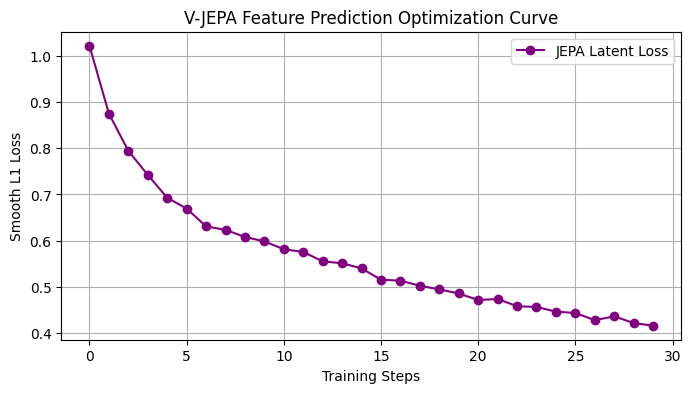

In [5]:
# Device Routing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Booting V-JEPA Workspace Engine on: {device}")

# Initialize Model, Optimizer, and Loss
model = VideoJEPA().to(device)
optimizer = optim.AdamW(
    list(model.tokenizer.parameters()) +
    list(model.context_encoder.parameters()) +
    list(model.predictor.parameters()),
    lr=1e-3, weight_decay=1e-4
)

# Smooth L1 is chosen in V-JEPA for robust convergence against out-of-distribution frames
criterion = nn.SmoothL1Loss()

# Simulate a video batch directly inside GPU memory
# Shapes correspond to: [Batch Size=16, Color Channels=3, Video Frames=4, Height=32, Width=32]
simulated_video_dataset = torch.randn(16, 3, 4, 32, 32).to(device)

loss_history = []

print("\n--- Training V-JEPA Latent Representation Space ---")
model.train()
for step in range(30):
    optimizer.zero_grad()

    # Process through abstract embedding configurations
    pred_latents, true_latents = model(simulated_video_dataset)

    # Minimize error purely on masked coordinates
    loss = criterion(pred_latents, true_latents)
    loss.backward()
    optimizer.step()

    # Anchor step for Exponential Moving Average tracker
    model.update_target_weights(momentum=0.99)

    loss_history.append(loss.item())
    if (step + 1) % 5 == 0 or step == 0:
        print(f"Step {step+1:02d}/30 | Spatio-Temporal Target L1 Loss: {loss.item():.5f}")

# Plotting the convergence performance
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o', color='purple', label='JEPA Latent Loss')
plt.title('V-JEPA Feature Prediction Optimization Curve')
plt.xlabel('Training Steps')
plt.ylabel('Smooth L1 Loss')
plt.grid(True)
plt.legend()
plt.show()